In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyro
import pyro.distributions as dist
import torch
import torch.nn as nn

from pathlib import Path
from pyro.nn import PyroModule, PyroSample
from pyro.infer import MCMC, NUTS, Predictive, HMC
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from typing import Callable

from utils.Reservoir import Reservoir
from utils.BNN import BayesianNeuralNetwork
from utils.forecast import recursive_forecast
from utils.data_generator import DataGenerator

### Generating synthetic dataset

In [2]:
time_steps = 100000
burnin_steps = 1000
stride = 15
test_size = 0.2
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, _ = DataGenerator(time_steps, tau, n, beta, gamma, delta_t).generate_data()

X = X[burnin_steps::stride, :]
T = torch.arange(X.shape[0])

X = torch.from_numpy(X).float()
X_train, X_test, T_train, T_test = train_test_split(
    X, T, test_size=test_size, shuffle=False
)

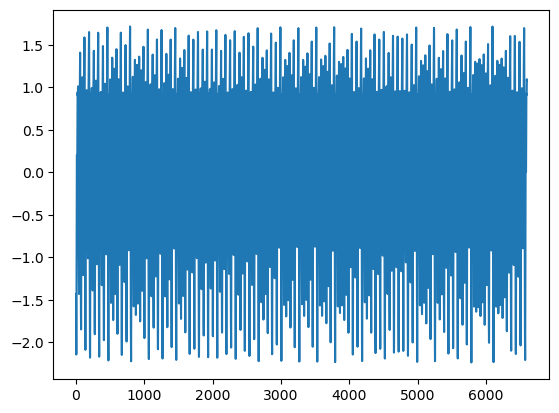

In [3]:
plt.plot(X)

### Defining the reservoir

In [4]:
n_reservoir = 20
K = X.shape[1]
reservoir = Reservoir(n_reservoir, K)

In [5]:
train_states = torch.zeros(X_train.shape[0] - 1, n_reservoir)
for t, x in enumerate(X_train[:-1]):
    train_states[t, :] = reservoir(x)
test_states = torch.zeros(X_test.shape[0], n_reservoir)
test_states[0, :] = reservoir(X_train[-1])
reservoir.save_state()
for t, x in enumerate(X_test[:-1]):
    test_states[t + 1, :] = reservoir(x)

### Defining the Bayesian model

In [6]:
class Model(PyroModule):
    def __init__(self, in_features: int, out_features: int, scale: float = 0.1):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.scale = scale
        return

    def forward(
        self,
        x: torch.Tensor,
        y: torch.Tensor | None = None,
    ):
        R = pyro.sample(
            "R",
            dist.Normal(0, 1).expand([self.in_features, self.out_features]).to_event(2),
        )
        mu = torch.matmul(x, R)
        sigma = pyro.sample(
            "sigma", dist.HalfNormal(self.scale).expand([self.out_features]).to_event(1)
        )
        with pyro.plate("data", x.shape[0]):
            pyro.sample("obs", dist.Normal(mu, sigma**2).to_event(1), obs=y)
        return mu

In [7]:
n_layers = 4
model = BayesianNeuralNetwork(
    [int(layer_size) for layer_size in np.linspace(n_reservoir, K, n_layers)], nn.ReLU()
)
# model = Model(n_reservoir, K)
# mcmc hyperparameters
num_samples = 100
warmup_steps = 100

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_samples, warmup_steps)
mcmc.run(train_states, X_train[1:])

Sample: 100%|██████████| 200/200 [22:58,  6.89s/it, step size=4.83e-04, acc. prob=0.828]


In [8]:
predictive = Predictive(model, posterior_samples=mcmc.get_samples())
y = predictive(test_states)

In [9]:
y["obs"].shape

torch.Size([100, 1320, 1])

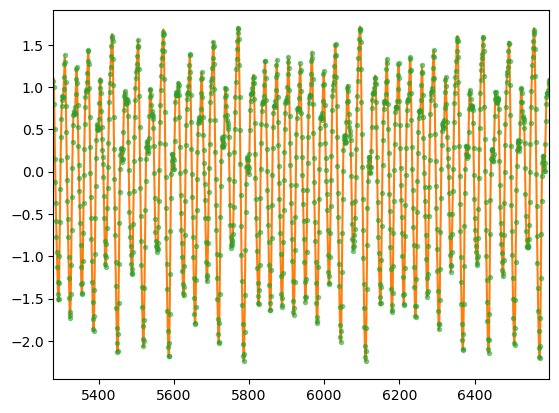

In [10]:
fig, ax = plt.subplots()
ax.plot(T_train, X_train)
ax.plot(T_test, X_test)
ax.errorbar(
    T_test,
    torch.mean(y["obs"], dim=0).reshape(-1),
    yerr=torch.std(y["obs"], dim=0).reshape(-1),
    fmt=".",
    alpha=0.5,
)
ax.set_xlim(T_test[0], T_test[-1])
plt.show()

In [11]:
reservoir.load_state()
chains = recursive_forecast(X_test[0, :].reshape(1, -1), predictive, reservoir, 80, 100)

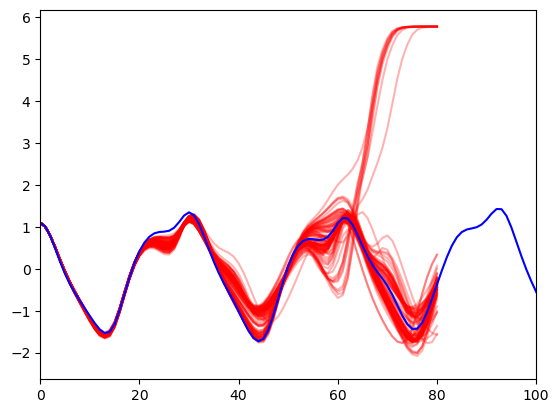

In [12]:
for c in chains:
    plt.plot(c, alpha=0.3, color="r", label="forecasts")
plt.plot(X_test, color="b", label="test")
plt.xlim(0, 100)
plt.show()

In [ ]:
def plot_forecast(chains: torch.Tensor, test: torch.Tensor):
    fig, ax = plt.subplots()
    avg = torch.mean(chains, dim=0).reshape(-1)
    std = torch.std(chains, dim=0).reshape(-1)

    ax.plot(test, color="b", label="true")
    ax.plot(avg, color="r", linestyle="--", label="avg forecast")
    ax.fill_between(
        torch.arange(avg.shape[0]),
        avg - std,
        avg + std,
        alpha=0.5,
        color="r",
        label=r"$\pm \sigma$",
        # label=r"95% C.I.",
    )
    ax.set_xlim(0, len(avg))

    ax.legend()
    fig.tight_layout()
    plt.show()
    return

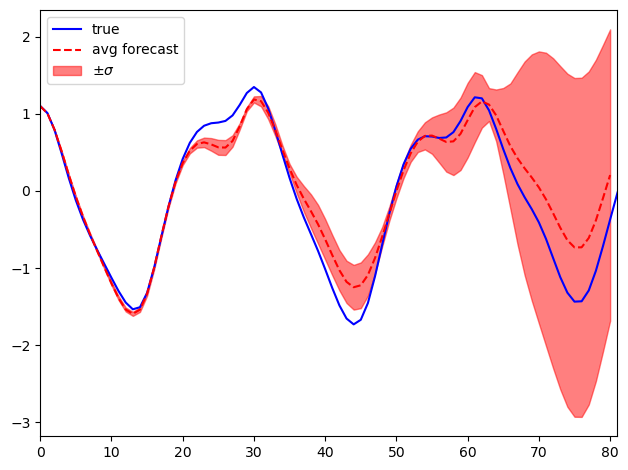

In [20]:
plot_forecast(chains, X_test)